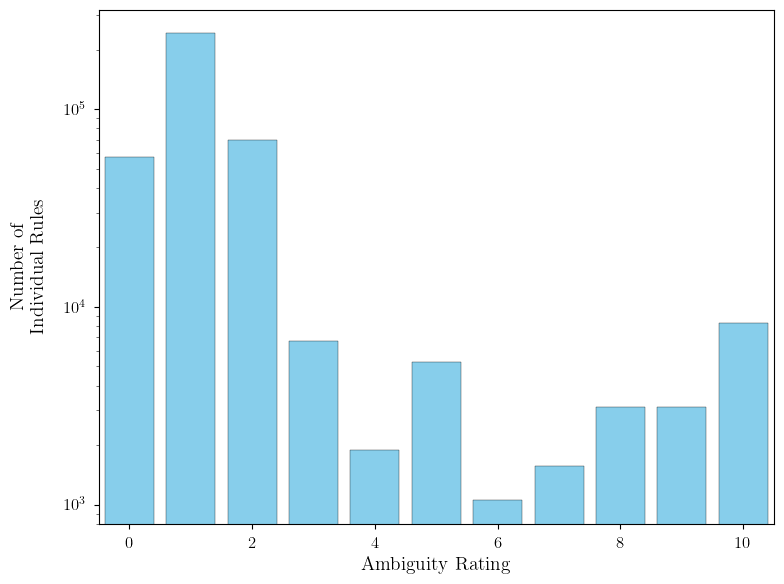

Histogram saved to ambiguity_histogram_log.png


In [2]:
#!/usr/bin/env python3
"""Notebook cell version of scripts/plot_ambiguity_histogram.py."""

from ast import literal_eval
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
from datasets import Dataset, load_dataset

DATASET_NAME = "tomg-group-umd/DynaBench"
SUBSET_NAME = "DynaBenchTrain"
SPLIT_NAME = "train"
OUTPUT_PATH = Path("ambiguity_histogram_log.png")
FIGSIZE = (8.0, 6.0)
USE_LOG_SCALE = True


def parse_ambiguity_chunks(chunks: Iterable[str]) -> list[int]:
    values: list[int] = []
    for chunk in chunks:
        assert isinstance(chunk, str), (
            f"Expected string ambiguity chunk, received {type(chunk)}: {chunk}"
        )
        stripped = chunk.strip()
        assert stripped, f"Ambiguity chunk is empty after stripping: {chunk}"
        prefix_split = stripped.split(". ", 1)
        assert len(prefix_split) == 2, (
            f"Ambiguity chunk missing numbered prefix: {chunk}"
        )
        list_text = prefix_split[1].strip()
        parsed = literal_eval(list_text)
        assert isinstance(parsed, list), (
            f"Expected list from literal_eval, received {type(parsed)}: {parsed}"
        )
        for entry in parsed:
            assert isinstance(entry, (int, float)), (
                f"Ambiguity entry must be numeric, received {entry} from chunk {chunk}"
            )
            values.append(int(entry))
    return values


def collect_ambiguities(dataset: Dataset) -> list[int]:
    all_values: list[int] = []
    for row_index, row in enumerate(dataset):
        chunks = row["ambiguity_by_rule_by_turn"]
        if chunks is None:
            continue
        assert isinstance(chunks, Sequence), (
            f"Row {row_index} has non-sequence ambiguity data: {chunks}"
        )
        all_values.extend(parse_ambiguity_chunks(chunks))
    assert all_values, "Parsed ambiguity list is empty."
    return all_values


def ensure_output_directory(output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)


def plot_histogram(values: Sequence[int], output_path: Path, figsize: tuple[float, float]) -> None:
    min_value = min(values)
    max_value = max(values)
    assert min_value <= max_value, (
        f"Invalid value range computed (min={min_value}, max={max_value})."
    )

    plt.style.use("seaborn-v0_8-paper")
    plt.rcParams["figure.figsize"] = figsize
    plt.rcParams["font.size"] = 12
    plt.rcParams["axes.labelsize"] = 14
    plt.rcParams["xtick.labelsize"] = 12
    plt.rcParams["ytick.labelsize"] = 12
    plt.rcParams["legend.fontsize"] = 12
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Computer Modern Roman"]
    plt.rcParams["text.usetex"] = True

    bins = np.arange(min_value - 0.5, max_value + 1.5, 1)
    plt.figure()
    plt.hist(
        values,
        bins=bins,
        color="skyblue",
        edgecolor="black",
        rwidth=0.8,
    )

    plt.xlabel("Ambiguity Rating")
    plt.ylabel("Number of\nIndividual Rules", rotation=90, labelpad=12)
    if USE_LOG_SCALE:
        plt.yscale("log")
    else:
        plt.yscale("linear")

    tick_step = max(1, int(np.ceil((max_value - min_value + 1) / 10)))
    start_tick = int(min_value)
    if (max_value - start_tick) % tick_step == 0 and max_value != start_tick:
        end_tick = int(max_value) + tick_step
    else:
        end_tick = int(
            start_tick + np.ceil((max_value - start_tick + 1) / tick_step) * tick_step
        )
    if min_value == max_value:
        start_tick = int(min_value)
        end_tick = int(min_value) + 1
        tick_step = 1

    plt.xticks(np.arange(start_tick, end_tick, step=tick_step))
    plt.xlim(bins[0], bins[-1])
    plt.tight_layout()
    save_kwargs = {"bbox_inches": "tight"}
    if output_path.suffix.lower() == ".pdf":
        save_kwargs["format"] = "pdf"
    plt.savefig(output_path, **save_kwargs)
    plt.show()
    plt.close()


dataset = load_dataset(DATASET_NAME, SUBSET_NAME, split=SPLIT_NAME)
values = collect_ambiguities(dataset)
ensure_output_directory(OUTPUT_PATH)
plot_histogram(values, OUTPUT_PATH, FIGSIZE)
print(f"Histogram saved to {OUTPUT_PATH}")


In [21]:
import matplotlib as mpl
import seaborn as sns

# --- Matplotlib configuration ---
# sns.set_palette("colorblind")
# mpl.rcParams.update({
#     # 'font.family': 'serif',
#     # 'font.serif': ['Times New Roman'],
#     'font.size': 10,
#     'axes.titlesize': 14,
#     'axes.labelsize': 12,
#     # 'xtick.labelsize': 9, # We will set this directly on the axes
#     'ytick.labelsize': 10,
#     'legend.fontsize': 10,
#     'figure.dpi': 300,
#     'savefig.dpi': 300,
#     'lines.linewidth': 1.5,
#     'axes.edgecolor': 'black',
#     'axes.linewidth': 1,
#     'grid.color': '0.8',
#     'grid.linestyle': '--'
# })
# mpl.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
# mpl.rc('text', usetex=True) # Remember this requires a LaTeX installation

In [60]:
import argparse
import os
import sys
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from utilities.compliance_dataset import ComplianceDataset, ComplianceExample

# dataset_path = "/Users/monte/code/system-prompt-compliance/output/base_data/compliance/compliance_base_data/train.jsonl"
# metadata_path = "/Users/monte/code/system-prompt-compliance/output/base_data/compliance/compliance_base_metadata/train_metadata.jsonl"
# args = argparse.Namespace(
#     main_dataset_path=dataset_path,
#     metadata_path=metadata_path,
#     hf_upload=False,
#     remove_mismatched_rows=False,
#     enforce_columns=False,
# )
# dataset = ComplianceDataset.load(args, dataset_path, metadata_path, hf=True)

dataset_path = "/Users/monte/code/system-prompt-compliance/output/base_data/compliance/compliance_base_data/test.jsonl"
metadata_path = "/Users/monte/code/system-prompt-compliance/output/base_data/compliance/compliance_base_metadata/test_metadata.jsonl"
args = argparse.Namespace(
    main_dataset_path=dataset_path,
    metadata_path=metadata_path,
    hf_upload=False,
    remove_mismatched_rows=False,
    enforce_columns=False,
)
test = ComplianceDataset.load(args, dataset_path, metadata_path, hf=True)

# df = dataset.to_pandas()

Generating _ split: 98 examples [00:00, 11309.76 examples/s]
Generating _ split: 98 examples [00:00, 18188.49 examples/s]


In [61]:
test.to_json("test_base_data.jsonl")

Creating json from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 47.91ba/s]


2263564

In [58]:
dataset.to_json("train_base_data.jsonl")

Creating json from Arrow format: 100%|██████████| 40/40 [00:01<00:00, 20.85ba/s]


402369598

In [ ]:
print("Median number of turns:", df["num_turns"].median())
print("Median number of rules:", df["num_rules"].median())
print("Maximum number of rules:", df["num_rules"].max())

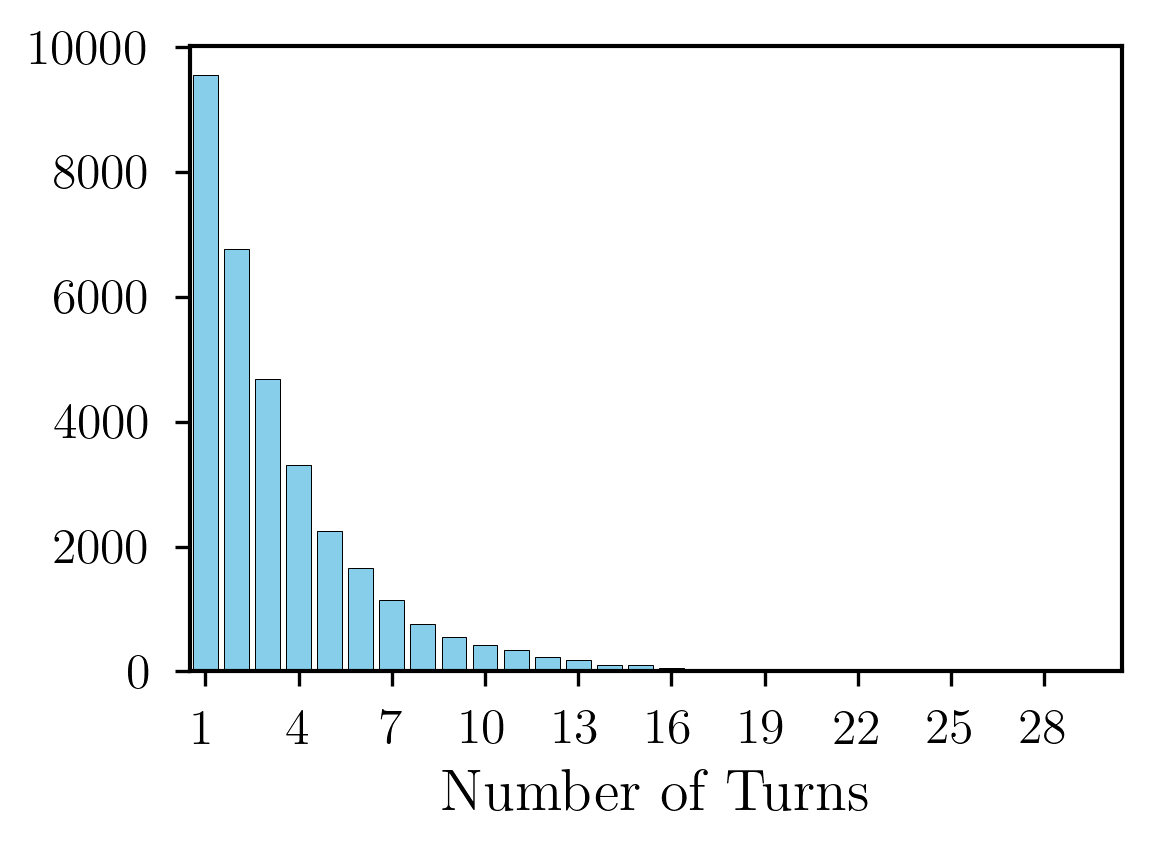

Histogram saved to histogram_num_turns.pdf


In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Histogram of Number of Turns ---

# 1. Define the data for the histogram
x = df['num_turns']

# 2. Set up the plot aesthetics
# For a small plot with large labels, suitable for a LaTeX paper
plt.style.use('seaborn-v0_8-paper') # A style that's generally good for papers
plt.rcParams['figure.figsize'] = (4, 3)  # Small figure size (width, height in inches)
plt.rcParams['font.size'] = 12           # Base font size for text elements
plt.rcParams['axes.labelsize'] = 14      # X and Y axis label size
plt.rcParams['xtick.labelsize'] = 12     # X tick label size
plt.rcParams['ytick.labelsize'] = 12     # Y tick label size
plt.rcParams['legend.fontsize'] = 12     # Legend font size (if you were to use one)

# Optional: For LaTeX-compatible fonts (uncomment if you have LaTeX installed and want this).
# This can sometimes require a LaTeX installation and may complicate things if not set up.
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman'] # Or 'Times New Roman', 'CMU Serif', etc.
plt.rcParams['text.usetex'] = True # This tells Matplotlib to use LaTeX for text rendering.

# 3. Create the histogram
# Define bins to be centered on integers.
# Bins should be e.g., [0.5, 1.5, 2.5, ..., max_val + 0.5]
# This handles cases where num_turns might not strictly be 1-30.
min_val = x.min()
max_val = x.max()
bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

plt.hist(x, bins=bins, color='skyblue', edgecolor='black', rwidth=0.8)

# 4. Set labels (no title as per academic convention)
plt.xlabel("Number of Turns")
# plt.ylabel("Frequency")

# 5. Customize ticks
# This attempts to create a reasonable number of integer ticks.
# Adjust the 'step' in np.arange for plt.xticks as needed for your specific data range.
tick_step = max(1, int(np.ceil((max_val - min_val + 1) / 10))) # Aim for around 10 ticks or less
start_tick = int(min_val)
# Ensure end_tick for np.arange covers the max_val
if (max_val - start_tick) % tick_step == 0 and max_val != start_tick : # Added condition for max_val != start_tick
    end_tick = int(max_val) + tick_step # Ensure the last tick is included
else:
    end_tick = int(start_tick + np.ceil((max_val - start_tick +1) / tick_step) * tick_step)
# Corrected edge case for single point data or when min_val = max_val
if min_val == max_val:
    start_tick = int(min_val)
    end_tick = int(min_val) +1
    tick_step = 1


plt.xticks(np.arange(start_tick, end_tick, step=tick_step))
plt.xlim(bins[0], bins[-1]) # Set x-axis limits to align with the edges of the first and last bins

# 6. Adjust layout to prevent labels from being cut off
plt.tight_layout()

# 7. Save the histogram as a PDF
# The `bbox_inches='tight'` option is good for trimming whitespace around the figure.
file_path = "histogram_num_turns.pdf"
plt.savefig(file_path, format='pdf', bbox_inches='tight')

# 8. Display the plot in the Jupyter Notebook
plt.show()

print(f"Histogram saved to {file_path}")

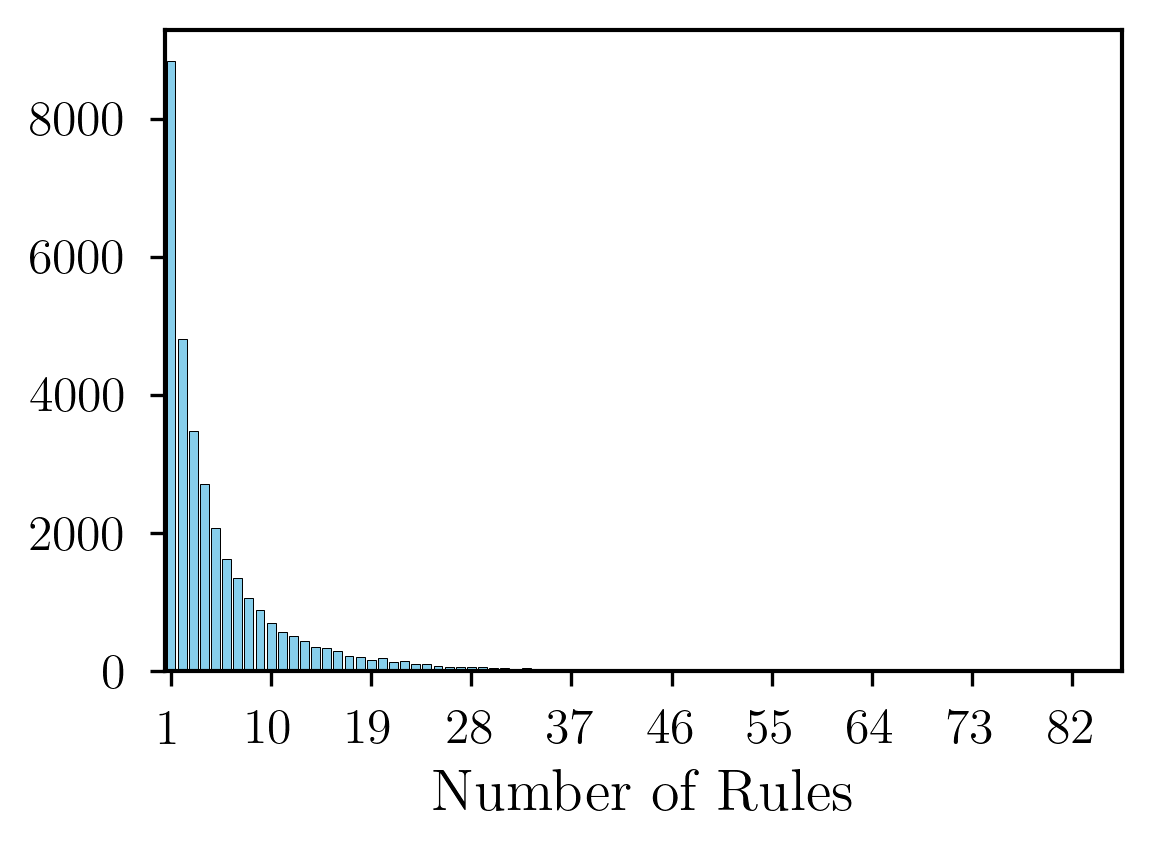

Histogram saved to histogram_num_rules.pdf


In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Histogram of Number of Rules ---

# 1. Define the data for the histogram
x = df['num_rules']

# 2. Set up the plot aesthetics
# For a small plot with large labels, suitable for a LaTeX paper
plt.style.use('seaborn-v0_8-paper') # A style that's generally good for papers
plt.rcParams['figure.figsize'] = (4, 3)  # Small figure size (width, height in inches)
plt.rcParams['font.size'] = 12           # Base font size for text elements
plt.rcParams['axes.labelsize'] = 14      # X and Y axis label size
plt.rcParams['xtick.labelsize'] = 12     # X tick label size
plt.rcParams['ytick.labelsize'] = 12     # Y tick label size
plt.rcParams['legend.fontsize'] = 12     # Legend font size (if you were to use one)

# Optional: For LaTeX-compatible fonts (uncomment if you have LaTeX installed and want this).
# This can sometimes require a LaTeX installation and may complicate things if not set up.
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman'] # Or 'Times New Roman', 'CMU Serif', etc.
plt.rcParams['text.usetex'] = True # This tells Matplotlib to use LaTeX for text rendering.

# 3. Create the histogram
# Define bins to be centered on integers.
# Bins should be e.g., [0.5, 1.5, 2.5, ..., max_val + 0.5]
# This handles cases where num_turns might not strictly be 1-30.
min_val = x.min()
max_val = x.max()
bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

plt.hist(x, bins=bins, color='skyblue', edgecolor='black', rwidth=0.8)

# 4. Set labels (no title as per academic convention)
plt.xlabel("Number of Rules")
# plt.ylabel("Frequency")

# 5. Customize ticks
# This attempts to create a reasonable number of integer ticks.
# Adjust the 'step' in np.arange for plt.xticks as needed for your specific data range.
tick_step = max(1, int(np.ceil((max_val - min_val + 1) / 10))) # Aim for around 10 ticks or less
start_tick = int(min_val)
# Ensure end_tick for np.arange covers the max_val
if (max_val - start_tick) % tick_step == 0 and max_val != start_tick : # Added condition for max_val != start_tick
    end_tick = int(max_val) + tick_step # Ensure the last tick is included
else:
    end_tick = int(start_tick + np.ceil((max_val - start_tick +1) / tick_step) * tick_step)
# Corrected edge case for single point data or when min_val = max_val
if min_val == max_val:
    start_tick = int(min_val)
    end_tick = int(min_val) +1
    tick_step = 1


plt.xticks(np.arange(start_tick, end_tick, step=tick_step))
plt.xlim(bins[0], bins[-1]) # Set x-axis limits to align with the edges of the first and last bins

# 6. Adjust layout to prevent labels from being cut off
plt.tight_layout()

# 7. Save the histogram as a PDF
# The `bbox_inches='tight'` option is good for trimming whitespace around the figure.
file_path = "histogram_num_rules.pdf"
plt.savefig(file_path, format='pdf', bbox_inches='tight')

# 8. Display the plot in the Jupyter Notebook
plt.show()

print(f"Histogram saved to {file_path}")

In [ ]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset('json', data_files='../output/full_outputs.jsonl')['train']

# Print the column headings
print(dataset.column_names)


/opt/homebrew/Caskroom/miniforge/base/envs/sys_prompt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 5720 examples [00:00, 149804.99 examples/s]

['num_failed', 'conversation', 'target_policy', 'target_policy_tag', 'target_policy_type', 'labels', 'explanations', 'confidences', 'policies', 'policy_tags', 'extra_policy_types', 'system_prompt', 'agent_metadata', 'user_metadata', 'num_turns', 'num_policies', 'augmentation', 'base_id']


Collected category counts: Counter({'industry': 66380, 'tasks': 42945, 'content': 42418, 'style': 20879, 'regulations': 9176})


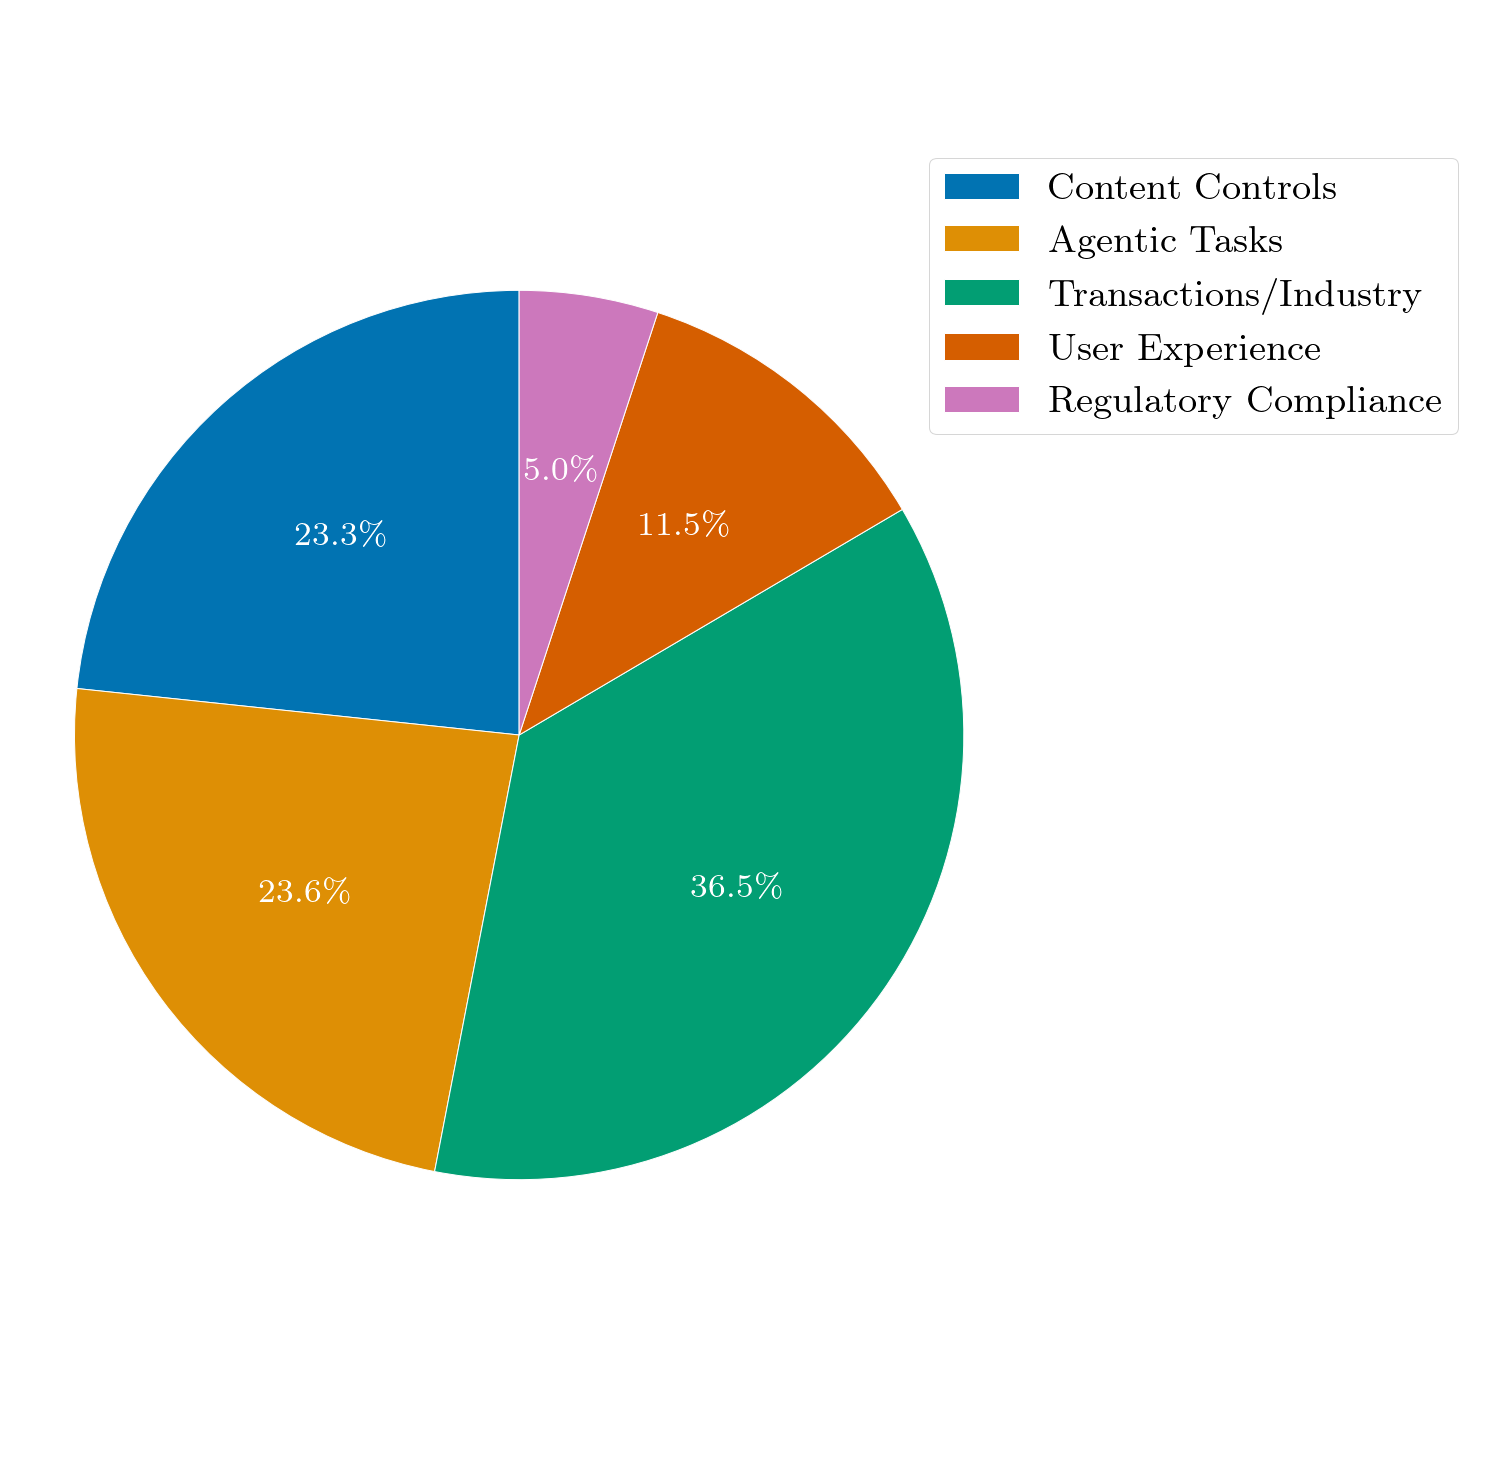

Pie chart saved to category_pie_chart.pdf


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # Used for Counter and easy data handling, can be adapted if not using df
from collections import Counter


# --- 2. Collect all category values ---
all_categories = []
# This assumes `data_iterator` is your Hugging Face dataset object or similar iterable
data_iterator = dataset # Use the simulated data

for row in data_iterator:
    if 'rule_tags' in row and row['rule_tags'] is not None: # Check if key exists and is not None
        for tag_dict in row['rule_tags']:
            if 'category' in tag_dict and tag_dict['category'] is not None: # Check key and value
                all_categories.append(tag_dict['category'])

# --- 3. Count the frequency of each category ---
category_counts = Counter(all_categories)

# --- Important Check for 6 Categories ---
# The user specified "There should be 6 different options for the categories."
# If you have more than 6, you might want to group the smallest ones into an "Other" category.
# Or, if you know the 6 specific categories, you can filter for them.
# For this example, we'll proceed with the counts as they are. If there are
# more than 6, the pie chart might become cluttered. If there are less, it will just show those.
# If strictly 6 are needed and data yields more, filtering or grouping is a next step.

print(f"Collected category counts: {category_counts}")
# Ensure we have data to plot. If category_counts is empty, plotting will fail.
if not category_counts:
    print("No categories found or 'rule_tags'/'category' structure is different. Aborting chart creation.")
else:
    # --- 4. Prepare data for the pie chart ---
    mapping = {
        "content": "Content Controls",
        "tasks": "Agentic Tasks",
        "industry": "Transactions/Industry",
        "style": "User Experience",
        "regulations": "Regulatory Compliance",
    }
    labels = [mapping[label] for label in list(category_counts.keys())]
    sizes = list(category_counts.values())

    # Sort by size for a potentially cleaner look (optional, largest to smallest)
    # Or sort by label if preferred. For now, using Counter's order.
    # sorted_pairs = sorted(category_counts.items(), key=lambda item: item[1], reverse=True)
    # labels = [pair[0] for pair in sorted_pairs]
    # sizes = [pair[1] for pair in sorted_pairs]


    # --- 5. Create the pie chart ---
    plt.style.use('seaborn-v0_8-paper') # Academic style
    plt.rcParams['figure.figsize'] = (5, 5)  # Slightly larger for pie chart clarity, but still compact
    plt.rcParams['font.size'] = 10           # Base font size
    plt.rcParams['axes.labelsize'] = 12      # For any potential axis labels (not typical for pie)
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10

    fig, ax = plt.subplots()

    # Custom colors can be defined if desired:
    # colors = plt.cm.Paired(np.linspace(0, 1, len(labels))) # Example using a colormap

    wedges, texts, autotexts = ax.pie(
        sizes,
        autopct='%1.1f%%',  # Show percentages on slices
        startangle=90,      # Start the first slice at the top
        # colors=colors,    # Uncomment to use custom colors
        wedgeprops={'edgecolor': 'white'} # Adds a fine white line between slices
    )

    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

    # --- 6. Customize for academic look ---
    # No title, as per academic conventions (caption will handle it)

    # Improve label and percentage text properties
    plt.setp(autotexts, size=8, weight="bold", color="white") # Make percentage text bold and white for contrast

    # Add a legend if there are many slices or labels overlap
    # For 6 categories, direct labels are usually fine, but a legend is an option.
    # If labels are long or numerous, a legend is better.
    # ax.legend(wedges, labels,
    #           title="Categories",
    #           loc="center left",
    #           bbox_to_anchor=(1, 0, 0.5, 1)) # Adjust bbox_to_anchor as needed

    # For 6 categories, a legend is generally good for academic papers.
    # Ensure legend font size is appropriate
    plt.rcParams['legend.fontsize'] = 9
    ax.legend(labels, loc='best', bbox_to_anchor=(0.9, 0.7)) # Adjust position as needed
    # You can also place it outside: bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout() # Adjust layout

    # --- 7. Save the chart ---
    pdf_file_path = "category_pie_chart.pdf"
    plt.savefig(pdf_file_path, format='pdf', bbox_inches='tight')
    plt.show()
    print(f"Pie chart saved to {pdf_file_path}")



Collected role counts (first 10): {'Technical Form-filling': 653, 'Best Practices Assistant': 686, 'Data Analyzer': 655, 'Customer Service': 11343, 'Entertainer': 685, 'Supervised Tool-using': 665, 'Internal Data Entry': 651, 'Content Creation': 648, 'Content Moderation': 657, 'Idea Generation for Brainstorming': 636}
Total unique roles: 32

--- Generating Pie Chart (Not Recommended for ~30 Categories) ---


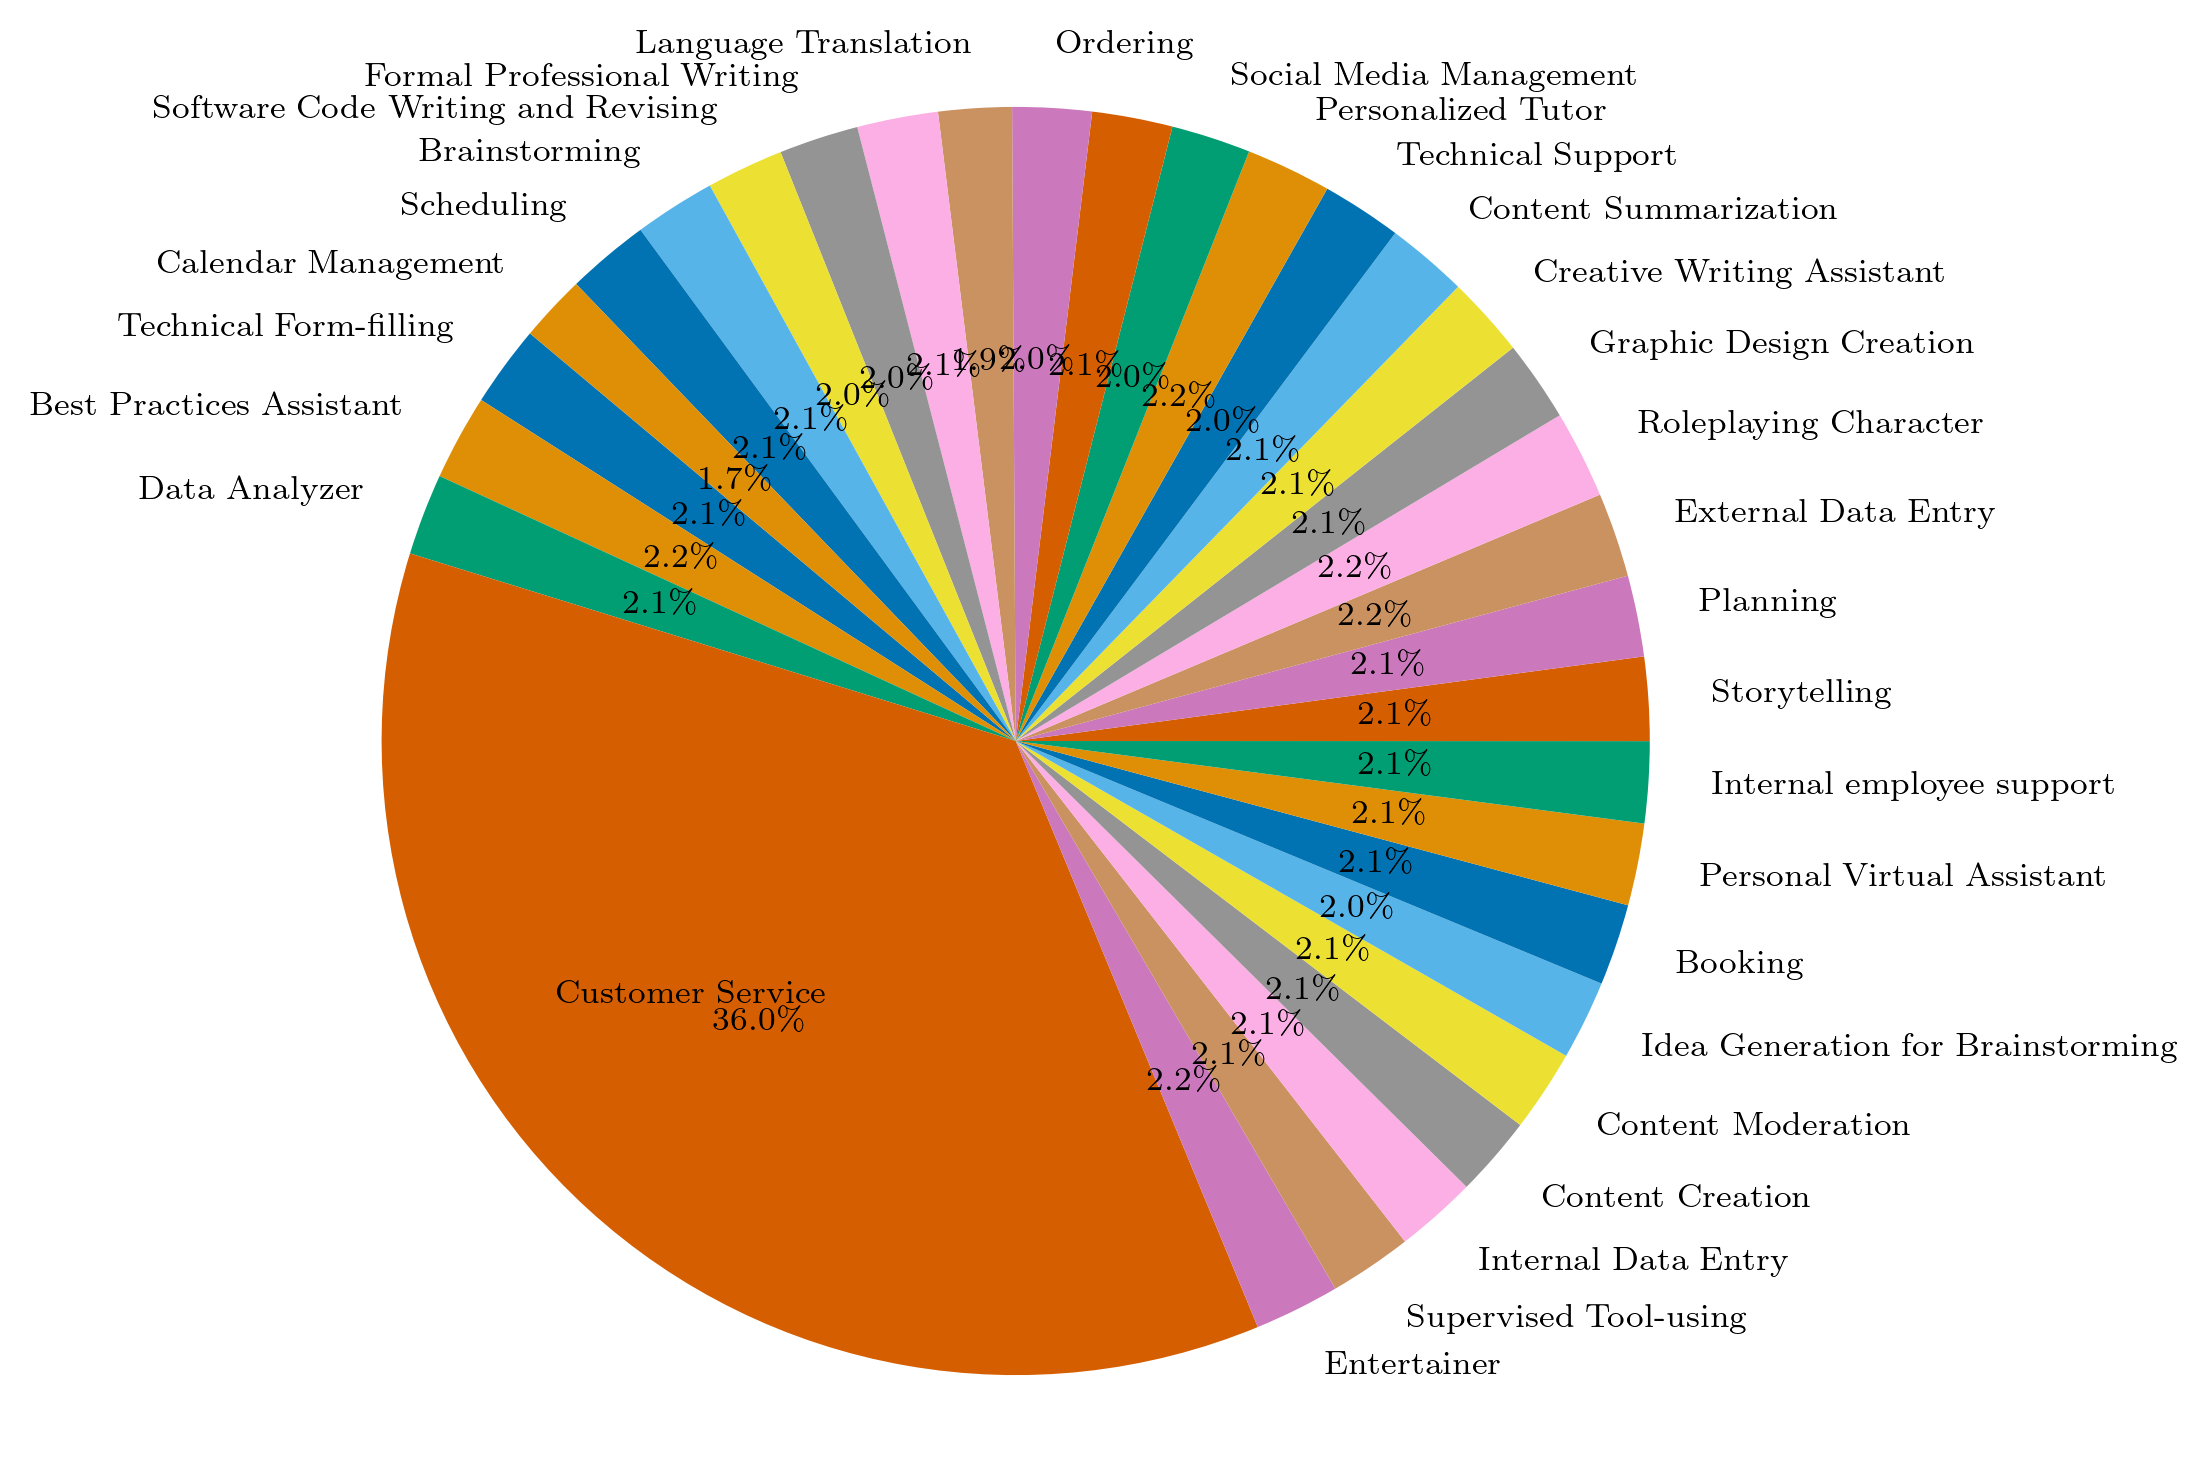

<Figure size 1800x1800 with 0 Axes>

Pie chart (not recommended) saved to role_pie_chart_30_categories.pdf


In [54]:
import matplotlib.pyplot as plt
import pandas as pd # For Counter and potential DataFrame use
from collections import Counter
import numpy as np
import random
import string # For generating sample role names

# --- 2. Collect all "role" values ---
all_roles = []
data_iterator_roles = dataset 

for row in data_iterator_roles:
    if 'agent_metadata' in row and row['agent_metadata'] is not None:
        metadata = row['agent_metadata']
        if 'role' in metadata and metadata['role'] is not None:
            all_roles.append(metadata['role'])

# Remove roles that are empty strings
all_roles = [role for role in all_roles if role != ""]
# --- 3. Count the frequency of each role ---
role_counts = Counter(all_roles)
print(f"Collected role counts (first 10): {dict(list(role_counts.items())[:10])}")
print(f"Total unique roles: {len(role_counts)}")

if not role_counts:
    print("No roles found or 'agent_metadata'/'role' structure is different. Aborting chart creation.")
else:
    # --- 4. PIE CHART (with strong recommendation against using it for ~30 categories) ---
    print("\n--- Generating Pie Chart (Not Recommended for ~30 Categories) ---")
    
    # Prepare data - for pie chart, often top N + 'Other' is better if many categories.
    # Here, we'll attempt to plot all as per the implicit request for "~30 values".
    pie_labels = list(role_counts.keys())
    pie_sizes = list(role_counts.values())

    plt.style.use('seaborn-v0_8-paper')
    sns.set_palette("colorblind")
    plt.rcParams['figure.figsize'] = (6, 6) # Slightly larger due to many potential labels
    plt.rcParams['font.size'] = 8 # Smaller base font due to potential clutter
    
    fig_pie, ax_pie = plt.subplots()
    
    # Map "Text Editing" and "Digital Art Creation" to empty string, others unchanged
    pie_labels = ["" if label in ["Text Editing", "Digital Art Creation"] else label for label in pie_labels]

    wedges, texts, autotexts = ax_pie.pie(pie_sizes, labels=pie_labels, autopct='%1.1f%%', startangle=140)

    # Adjust the position of the "Customer Service" label
    for i, text in enumerate(texts):
        if text.get_text() == "Customer Service":
            text.set_position((-0.3, -0.4))  # Position it on top of the pie
            # text.set_color('white')

    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    # plt.title('Agent Role Types', pad=20, fontsize=16)  # Add more space between the title and the plot and increase font size
    plt.show()

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust rect to make space for legend outside

    pdf_file_path_pie = "role_pie_chart_30_categories.pdf"
    plt.savefig(pdf_file_path_pie, format='pdf', bbox_inches='tight')
    plt.show() # Showing pie chart might be very slow/cluttered
    print(f"Pie chart (not recommended) saved to {pdf_file_path_pie}")
    plt.close(fig_pie) # Close the figure to free memory
  